# Week 02 - Lesson 02: Tool Management in AI Agents

## Overview

In this lesson, we'll explore **Tools** - the core components that enable AI agents to interact with external systems and perform real-world actions. We'll progress from basic tool concepts to advanced tool selection strategies used in production systems.

### Learning Objectives
By the end of this notebook, you will:
1. Understand tool
2. Implement dynamic tool selection using vector similarity
3. Build sophisticated agents with custom tool management workflows
4. Apply tool selection strategies for large-scale deployments

In `Week 01`, we introduced the concept of tools. Now, we'll dive deeper to truly understand what tools are and how they empower AI agents to interact with the world.

In `Week 02 - Lesson 01`, we discussed vanilla RAG (Retrieval-Augmented Generation), where we focused on retrieving relevant information from a database to enhance agent responses. Now, since we're talking about `Tools`, why not combine both concepts? 

Let's create an agent that has access to multiple tools, but instead of statically assigning them, the agent will retrieve and select tools dynamically using a similarity search system—just like performing a retrieval of the most relevant tools from a vector database and choosing which ones to use for each task.
 
However, it's important to clarify that what we are about to build **is not** a RAG system. In RAG, the retrieval step is used to augment the LLM's response with external information. 

Here, we use retrieval only to select the most relevant tools for the agent to use, not to directly enhance the response content. The retrieval process helps the LLM decide which tool to call, but the retrieved data (the tools available) itself is not injected directly into the final answer.


<img src="https://miro.medium.com/v2/da:true/resize:fit:1200/0*oQeySK6iAxYm_V1M" alt="Tools" style="max-width: 90%;" />

---


## 1. Environment Setup

We'll set up a comprehensive environment for building advanced AI agents with sophisticated tool management capabilities.


In [1]:
# Install required packages for advanced tool management
%pip install -U --quiet langchain langchain-openai langchain-tavily langgraph python-dotenv numpy

Note: you may need to restart the kernel to use updated packages.


In [16]:
import os
os.environ["OPENAI_API_KEY"] = "sk-your-api-key-here"

In [3]:
# Import necessary libraries for advanced tool management
import os
import uuid
from typing import Annotated, TypedDict
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

# Load environment variables
load_dotenv()

# Initialize the LLM
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.1,
    api_key=os.getenv('OPENAI_API_KEY')
)

print("✅ Advanced environment setup complete!")


✅ Advanced environment setup complete!


---

## 2. Tool Architecture in Production Systems

**Tools** are the interface between AI agents and external systems. In production environments, tools represent:

- **Data Access Layer**: Connect to databases, APIs, and external services
- **Business Logic**: Implement domain-specific operations and calculations
- **Integration Points**: Bridge between AI reasoning and system capabilities
- **Action Execution**: Perform real-world operations and state changes

### Tool Design Principles

- **Scalability**: As systems grow, tool selection becomes critical for performance
- **Modularity**: Tools should be independent, testable, and reusable
- **Reliability**: Proper error handling and fallback mechanisms
- **Security**: Controlled access to sensitive operations and data

### Advanced Tool Management Challenges

- **Tool Selection**: Choosing the right tools from hundreds of available options
- **Context Awareness**: Tools must understand current conversation state
- **Performance Optimization**: Minimizing token usage and response time
- **Error Recovery**: Handling tool failures and retry strategies

---


## 3. Creating Tools

Let's create a suite of financial analysis tools that demonstrate real-world tool design patterns.

Here we create example tools using the `@tool` decorator. 

These tools are Python functions with well-defined parameters and clear descriptions `docstrings`, as these are the key elements a language model will analyze to autonomously decide whether to call a tool or not.

The following examples are mock implementations simulating a financial analysis scenario, demonstrating how to structure tools for real-world applications.

In [4]:
# Financial Analysis Tools
from langchain_core.tools import tool
import numpy as np

# Note that we can use the @tool decorator to define a tool.
# It's mandatory to add a description to the tool using the docstring. Because this definition is what will be shown to the LLM to use the tool.
@tool
def portfolio_analyzer(holdings: str, weights: str) -> str:
    """Analyze portfolio composition and calculate key metrics.
    
    Args:
        holdings: Comma-separated list of asset symbols (e.g., 'AAPL,GOOGL,MSFT')
        weights: Comma-separated list of portfolio weights (e.g., '0.4,0.3,0.3')
    
    Returns:
        Portfolio analysis including diversification metrics and risk assessment
    """
    try:
        symbols = [s.strip().upper() for s in holdings.split(',')]
        weight_list = [float(w.strip()) for w in weights.split(',')]
        
        if len(symbols) != len(weight_list):
            return "Error: Number of holdings must match number of weights"
        
        if abs(sum(weight_list) - 1.0) > 0.01:
            return "Error: Portfolio weights must sum to 1.0"
        
        # Mock portfolio analysis
        total_weight = sum(weight_list)
        max_weight = max(weight_list)
        diversification_score = 1 - max_weight  # Simple diversification metric
        
        analysis = f"""
        Portfolio Analysis:
        - Assets: {', '.join(symbols)}
        - Total Weight: {total_weight:.2%}
        - Largest Position: {max_weight:.2%}
        - Diversification Score: {diversification_score:.2f}
        - Risk Level: {'Low' if diversification_score > 0.7 else 'Medium' if diversification_score > 0.4 else 'High'}
        """
        
        return analysis.strip()
        
    except Exception as e:
        return f"Error analyzing portfolio: {str(e)}"

@tool
def market_metrics(symbol: str, period: str = "1Y") -> str:
    """Get key market metrics for a financial instrument.
    
    Args:
        symbol: Stock symbol (e.g., 'AAPL', 'GOOGL')
        period: Analysis period ('1M', '3M', '6M', '1Y', '2Y')
    
    Returns:
        Market metrics including price, volatility, and performance indicators
    """
    # Mock market data - in production, this would connect to financial APIs
    mock_data = {
        "AAPL": {"price": 175.50, "volatility": 0.25, "return_1y": 0.15},
        "GOOGL": {"price": 2850.75, "volatility": 0.30, "return_1y": 0.08},
        "MSFT": {"price": 415.20, "volatility": 0.22, "return_1y": 0.12},
        "TSLA": {"price": 245.80, "volatility": 0.45, "return_1y": -0.05}
    }
    
    symbol = symbol.upper()
    if symbol not in mock_data:
        return f"Market data not available for {symbol}"
    
    data = mock_data[symbol]
    
    metrics = f"""
    Market Metrics for {symbol}:
    - Current Price: ${data['price']:.2f}
    - Volatility (1Y): {data['volatility']:.1%}
    - 1-Year Return: {data['return_1y']:.1%}
    - Risk Level: {'High' if data['volatility'] > 0.35 else 'Medium' if data['volatility'] > 0.25 else 'Low'}
    - Performance: {'Outperforming' if data['return_1y'] > 0.10 else 'Underperforming'}
    """
    
    return metrics.strip()

@tool
def risk_calculator(portfolio_value: float, volatility: float, confidence_level: float = 0.95) -> str:
    """Calculate Value at Risk (VaR) for portfolio risk assessment.
    
    Args:
        portfolio_value: Total portfolio value in USD
        volatility: Portfolio volatility (annualized)
        confidence_level: Confidence level for VaR calculation (default 0.95)
    
    Returns:
        Risk metrics including VaR and expected shortfall
    """
    try:
        # VaR calculation using normal distribution assumption
        z_score = 1.96 if confidence_level == 0.95 else 2.33 if confidence_level == 0.99 else 1.65
        
        # Daily VaR (assuming 252 trading days)
        daily_volatility = volatility / np.sqrt(252)
        var_daily = portfolio_value * z_score * daily_volatility
        
        # Annual VaR
        var_annual = portfolio_value * z_score * volatility
        
        risk_analysis = f"""
        Risk Analysis:
        - Portfolio Value: ${portfolio_value:,.2f}
        - Volatility: {volatility:.1%}
        - Confidence Level: {confidence_level:.0%}
        - Daily VaR: ${var_daily:,.2f}
        - Annual VaR: ${var_annual:,.2f}
        - Risk Rating: {'High' if volatility > 0.30 else 'Medium' if volatility > 0.20 else 'Low'}
        """
        
        return risk_analysis.strip()
        
    except Exception as e:
        return f"Error calculating risk metrics: {str(e)}"

print("✅ Financial tools created!")


✅ Financial tools created!


In [5]:
# Test the financial tools directly
print("📊 Testing Portfolio Analyzer:")
portfolio_result = portfolio_analyzer.invoke({"holdings": "AAPL,GOOGL,MSFT", "weights": "0.4,0.3,0.3"})
print(portfolio_result)

print("\n📈 Testing Market Metrics:")
market_result = market_metrics.invoke({"symbol": "AAPL", "period": "1Y"})
print(market_result)

print("\n⚠️ Testing Risk Calculator:")
risk_result = risk_calculator.invoke({"portfolio_value": 100000, "volatility": 0.25, "confidence_level": 0.95})
print(risk_result)

📊 Testing Portfolio Analyzer:
Portfolio Analysis:
        - Assets: AAPL, GOOGL, MSFT
        - Total Weight: 100.00%
        - Largest Position: 40.00%
        - Diversification Score: 0.60
        - Risk Level: Medium

📈 Testing Market Metrics:
Market Metrics for AAPL:
    - Current Price: $175.50
    - Volatility (1Y): 25.0%
    - 1-Year Return: 15.0%
    - Risk Level: Low
    - Performance: Outperforming

⚠️ Testing Risk Calculator:
Risk Analysis:
        - Portfolio Value: $100,000.00
        - Volatility: 25.0%
        - Confidence Level: 95%
        - Daily VaR: $3,086.71
        - Annual VaR: $49,000.00
        - Risk Rating: Medium


---

## 4. Dynamic Tool Selection System

In production systems, agents often have access to many tools. Dynamic tool selection using vector similarity allows agents to choose the most relevant tools for the current context.

It's important to note that this is not RAG (Retrieval-Augmented Generation). Here, we use retrieval and similarity search only to select which tools the LLM should use, not to augment or provide additional information for the model's response.


In [6]:
# Create a comprehensive tool registry
def create_tool_registry():
    """Create a registry of financial analysis tools with unique identifiers."""
    tools = [
        portfolio_analyzer,
        market_metrics, 
        risk_calculator
    ]
    
    # Create registry with UUID keys
    tool_registry = {}
    for tool in tools:
        tool_id = str(uuid.uuid4())
        tool_registry[tool_id] = tool
    
    return tool_registry

# Initialize tool registry
tool_registry = create_tool_registry()

print(f"✅ Tool registry created with {len(tool_registry)} tools")
print("Available tools:")
for tool_id, tool in tool_registry.items():
    print(f"  - {tool.name}: {tool.description[:60]}...")


✅ Tool registry created with 3 tools
Available tools:
  - portfolio_analyzer: Analyze portfolio composition and calculate key metrics.

  ...
  - market_metrics: Get key market metrics for a financial instrument.

    Args...
  - risk_calculator: Calculate Value at Risk (VaR) for portfolio risk assessment....


In [7]:
# Create vector store for tool selection
def setup_tool_vector_store():
    """Set up vector store for semantic tool selection."""
    # Create documents for each tool
    tool_documents = [
        Document(
            page_content=tool.description,
            id=tool_id,
            metadata={"tool_name": tool.name}
        )
        for tool_id, tool in tool_registry.items()
    ]
    
    # Initialize vector store with embeddings
    vector_store = InMemoryVectorStore(embedding=OpenAIEmbeddings())
    vector_store.add_documents(tool_documents)
    
    return vector_store

# Initialize vector store
vector_store = setup_tool_vector_store()
print("✅ Vector store initialized for tool selection")


✅ Vector store initialized for tool selection


---

## 5. Agent Architecture with Custom State

We'll build an agent using LangGraph with custom state management and dynamic tool selection capabilities.


In [8]:
# Define custom state for our agent
class AgentState(TypedDict):
    """State structure for our financial analysis agent."""
    messages: Annotated[list, add_messages]
    selected_tools: list[str]
    analysis_context: dict  # Store analysis results and context

print("✅ Agent state configured!")

✅ Agent state configured!


In [9]:
# Tool selection function using vector similarity
def select_tools(state: AgentState) -> dict:
    """Select relevant tools based on user query using vector similarity."""
    last_message = state["messages"][-1]
    
    if isinstance(last_message, HumanMessage):
        query = last_message.content
    else:
        # For non-human messages, use a default query
        query = "financial analysis tools"
    
    # Search for relevant tools using vector similarity
    tool_documents = vector_store.similarity_search(query, k=3)
    selected_tool_ids = [doc.id for doc in tool_documents]
    
    return {
        "selected_tools": selected_tool_ids,
        "analysis_context": {"query": query, "selection_method": "vector_similarity"}
    }

# Agent function with dynamic tool binding
def financial_agent(state: AgentState) -> dict:
    """Main agent function that processes requests with selected tools."""
    # Get selected tools from registry
    selected_tools = [tool_registry[tool_id] for tool_id in state["selected_tools"]]
    
    # Bind tools to LLM
    llm_with_tools = llm.bind_tools(selected_tools)
    
    # Create system message for financial analysis context
    system_message = SystemMessage(content="""
    You are a professional financial analyst AI assistant. You have access to specialized tools for:
    - Portfolio analysis and risk assessment
    - Market metrics and performance evaluation  
    - Risk calculations including VaR
    - Market research and current information
    
    Always provide professional, data-driven analysis with clear explanations.
    Use the most appropriate tools for each request.
    """)
    
    # Combine system message with conversation history
    messages = [system_message] + state["messages"]
    
    # Get LLM response
    response = llm_with_tools.invoke(messages)
    
    return {"messages": [response]}

print("✅ Agent functions defined!")


✅ Agent functions defined!


---

## 6. Building the Agent Graph

Now we'll construct the complete LangGraph with custom workflow and tool management.

In [10]:
# Build the complete agent graph
def build_financial_agent_graph():
    """Build the complete LangGraph for financial analysis agent."""
    
    # Initialize graph builder
    builder = StateGraph(AgentState)
    
    # Add nodes
    builder.add_node("select_tools", select_tools)
    builder.add_node("agent", financial_agent)
    
    # Create tool node with all available tools
    all_tools = list(tool_registry.values())
    tool_node = ToolNode(tools=all_tools)
    builder.add_node("tools", tool_node)
    
    # Define edges
    builder.add_edge(START, "select_tools")
    builder.add_edge("select_tools", "agent")
    builder.add_conditional_edges(
        "agent",
        tools_condition,
        path_map=["tools", "__end__"]
    )
    builder.add_edge("tools", "agent")
    
    return builder.compile()

# Build and compile the graph
financial_agent_graph = build_financial_agent_graph()

print("✅ Complete financial agent graph built!")
print("Graph structure:")
print("- Entry point: select_tools")
print("- Tool selection: vector similarity based")
print("- Agent processing: dynamic tool binding")
print("- Tool execution: conditional routing")

✅ Complete financial agent graph built!
Graph structure:
- Entry point: select_tools
- Tool selection: vector similarity based
- Agent processing: dynamic tool binding
- Tool execution: conditional routing


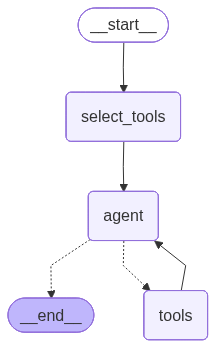

In [11]:
from IPython.display import Image, display

display(Image(financial_agent_graph.get_graph().draw_mermaid_png()))

In [12]:
# Test the financial agent with portfolio analysis
print("📊 Testing Portfolio Analysis:")
portfolio_response = financial_agent_graph.invoke({
    "messages": [("user", "Analyze a portfolio with 40% AAPL, 30% GOOGL, and 30% MSFT")]
})

print("Selected tools:", portfolio_response["selected_tools"])
print("Analysis context:", portfolio_response["analysis_context"])
print("\nAgent Response:")
print(portfolio_response["messages"][-1].content)

📊 Testing Portfolio Analysis:
Selected tools: ['6dc955ea-fd85-47ac-80ce-a99b80cb8e08', '118ecb27-b087-4374-aa58-89a25b760d40', '376fcabb-a546-4a6e-9dad-48da4b77e301']
Analysis context: {'query': 'Analyze a portfolio with 40% AAPL, 30% GOOGL, and 30% MSFT', 'selection_method': 'vector_similarity'}

Agent Response:
### Portfolio Analysis Summary

- **Assets**: AAPL, GOOGL, MSFT
- **Total Weight**: 100.00%
- **Largest Position**: 40.00% (AAPL)
- **Diversification Score**: 0.60 (on a scale from 0 to 1, where 1 indicates maximum diversification)
- **Risk Level**: Medium

### Insights:
1. **Concentration**: The portfolio has a significant concentration in AAPL, which constitutes 40% of the total holdings. This could lead to higher risk if AAPL underperforms.
  
2. **Diversification**: A diversification score of 0.60 indicates moderate diversification. While the portfolio includes three different assets, the weight distribution suggests that it may not be fully optimized for risk mitigation.


In [13]:
# Test with risk analysis request
print("⚠️ Testing Risk Analysis:")
risk_response = financial_agent_graph.invoke({
    "messages": [("user", "Calculate the VaR for a $500,000 portfolio with 30% volatility")]
})

print("Selected tools:", risk_response["selected_tools"])
print("\nAgent Response:")
print(risk_response["messages"][-1].content)

⚠️ Testing Risk Analysis:
Selected tools: ['376fcabb-a546-4a6e-9dad-48da4b77e301', '6dc955ea-fd85-47ac-80ce-a99b80cb8e08', '118ecb27-b087-4374-aa58-89a25b760d40']

Agent Response:
The Value at Risk (VaR) analysis for your $500,000 portfolio with a volatility of 30% is as follows:

- **Portfolio Value:** $500,000.00
- **Volatility:** 3000.0% (This seems unusually high; typically, volatility is expressed as a percentage, e.g., 30% should be 0.30 in calculations.)
- **Confidence Level:** 95%
- **Daily VaR:** $1,852,025.92
- **Annual VaR:** $29,400,000.00
- **Risk Rating:** High

### Interpretation:
- The Daily VaR indicates that there is a 95% confidence that the portfolio will not lose more than approximately $1.85 million in a single day.
- The Annual VaR suggests that there is a 95% confidence that the portfolio will not lose more than about $29.4 million over the course of a year.

### Note:
The volatility value appears to be incorrectly interpreted as 3000%. Please verify the volatil

---

## 7. Adding Web Search Capability to the Agent

<img src="https://tavily.com/twitter-image.png?95e47a33c8b932af" alt="Tavily Web Search" width="700">

In this section, we'll demonstrate how to extend our agent by integrating a new tool that enables web search functionality using `Tavily`. By adding the Tavily Search tool, our agent can access up-to-date information from the web, such as the latest market trends or financial news, making its responses more relevant and current.

> **Note:** Tavily requires an API key for access. The service offers a free tier, but you will need to register to obtain your key. If you prefer not to sign up, you can still follow along with the notebook: we provide logs of previous interactions so you can review the results without running the live search.


In [ ]:
from langchain_tavily import TavilySearch

os.environ["TAVILY_API_KEY"] = "tvly-dev-your-api-key-here"   

# Initialize Tavily Search
tavily_search = TavilySearch(
    max_results=3,
    topic="finance"  # Focus on financial information
)

# Add search tool to registry
search_tool_id = str(uuid.uuid4())
tool_registry[search_tool_id] = tavily_search

# Reinitialize the vector store with the new tool
vector_store = setup_tool_vector_store()

# Recompile the graph with the new tool
financial_agent_graph = build_financial_agent_graph()

print("✅ Agent with search capabilities configured!\n")

print(f"Total tools in registry: {len(tool_registry)}")
print("Available tools:")
for tool_id, tool in tool_registry.items():
    print(f"  - {tool.name}: {tool.description[:60]}...")


✅ Agent with search capabilities configured!

Total tools in registry: 4
Available tools:
  - portfolio_analyzer: Analyze portfolio composition and calculate key metrics.

  ...
  - market_metrics: Get key market metrics for a financial instrument.

    Args...
  - risk_calculator: Calculate Value at Risk (VaR) for portfolio risk assessment....
  - tavily_search: A search engine optimized for comprehensive, accurate, and t...


In [15]:
# Test with market research request
print("🔍 Testing Market Research:")

market_response = financial_agent_graph.invoke({
    "messages": [("user", "What are the current market trends for technology stocks?")]
})

print("Selected tools:", market_response["selected_tools"])
print("\nAgent Response:")
print(market_response["messages"][-1].content)

🔍 Testing Market Research:
Selected tools: ['582e0b94-10e4-4e98-9727-072632a07703', '118ecb27-b087-4374-aa58-89a25b760d40', '6dc955ea-fd85-47ac-80ce-a99b80cb8e08']

Agent Response:
Current market trends for technology stocks indicate a mixed performance, with some stocks showing significant growth while others are experiencing volatility. Here are some key insights:

1. **Mixed Performance**: The U.S. stock market has been experiencing a mixed performance overall, with major indices like the S&P 500 and Dow Jones Industrial showing fluctuations.

2. **High Growth Stocks**: Certain technology stocks are highlighted as having strong growth potential. For instance, companies like Yiren Digital and Quantum Computing have been noted for their value and growth prospects.

3. **Market Sentiment**: The overall sentiment in the technology sector appears to be cautiously optimistic, with investors keeping an eye on economic indicators and market conditions that could affect tech stock performanc

---

## 8. Recap: What We Learned About Tools
 
### **Key Concepts:**

1. **Tools as Interfaces**: Connect AI agents to external systems and real-world operations
2. **Tool Registry**: Centralized system to manage multiple tools with unique identifiers
3. **Dynamic Selection**: Intelligent tool selection based on semantic similarity
4. **State Management**: Preserves context and state during workflow execution


### **Tools Created:**

- **`portfolio_analyzer`**: Analyzes portfolio composition and diversification
- **`market_metrics`**: Provides market metrics (price, volatility, performance)
- **`risk_calculator`**: Calculates Value at Risk (VaR) for risk management
- **`tavily_search`**: Real-time market search

### **Intelligent Selection System:**

1. **Vector Similarity**: Uses embeddings to find relevant tools
2. **Context Awareness**: Considers conversation context for reselection
3. **Performance**: Scalable to hundreds of tools

### **Practical Example - Full Workflow:**

```python
# 1. User asks a question
"Analyze my portfolio with 50% AAPL, 30% GOOGL, 20% MSFT"

# 2. System selects relevant tools
selected_tools = ["portfolio_analyzer", "market_metrics", "risk_calculator"]

# 3. Agent processes with selected tools
agent_response = llm_with_tools.invoke(messages)

# 4. Tools are executed
portfolio_analysis = portfolio_analyzer.invoke({"holdings": "AAPL,GOOGL,MSFT", "weights": "0.5,0.3,0.2"})

# 5. Final response is generated
final_response = "Your portfolio shows..."
```
---